In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from tdc.single_pred import HTS, ADME
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from rdkit import DataStructs

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    mean_absolute_error, r2_score
)

In [2]:
# Download the data for classification (HTS) and regression (ADME)
HIV_data = HTS(name = 'HIV') #https://tdcommons.ai/single_pred_tasks/hts/?utm_source#hiv:~:text=BY%204.0.-,HIV,benchmark%20for%20molecular%20machine%20learning.%E2%80%9D%20Chemical%20science%209.2%20(2018)%3A%20513%2D530.,-Dataset%20License%3A 

caco2_data = ADME(name = 'Caco2_Wang') #https://tdcommons.ai/single_pred_tasks/adme/#caco-2-cell-effective-permeability-wang-et-al:~:text=site%20of%20action.-,Caco%2D2%20(Cell%20Effective%20Permeability)%2C%20Wang%20et%20al.,Journal%20of%20Chemical%20Information%20and%20Modeling%202016%2056%20(4)%2C%20763%2D773,-Dataset%20License%3A


HIV_df = HIV_data.get_data()
caco2_df = caco2_data.get_data()

print(f"Shape of HIV data: {HIV_df.shape}")
print(f"Shape of caco2 dataframe: {caco2_df.shape}")

display(HIV_df.head())
display(caco2_df.head())
# Y in HIV (classification is a regression label: )

Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


Shape of HIV data: (41127, 3)
Shape of caco2 dataframe: (910, 3)


,Drug_ID,Drug,Y
0,Drug 0,CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)...,0
1,Drug 1,C(=Cc1ccccc1)C1=[O+][Cu-3]2([O+]=C(C=Cc3ccccc3...,0
2,Drug 2,CC(=O)N1c2ccccc2Sc2c1ccc1ccccc21,0
3,Drug 3,Nc1ccc(C=Cc2ccc(N)cc2S(=O)(=O)O)c(S(=O)(=O)O)c1,0
4,Drug 4,O=S(=O)(O)CCS(=O)(=O)O,0


,Drug_ID,Drug,Y
0,(-)-epicatechin,Oc1cc(O)c2c(c1)OC(c1ccc(O)c(O)c1)C(O)C2,-6.220000
1,"(2E,4Z,8Z)-N-isobutyldodeca-2,4,10-triene-8 -y...",C/C=C\C#CCC/C=C\C=C\C(=O)NCC(C)C,-3.860000
2,codeine,COc1ccc2c3c1O[C@H]1[C@@H](O)C=C[C@H]4[C@@H](C2...,-4.090000
3,creatinine,CN1CC(=O)NC1=N,-5.935409
4,danazol,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=Cc5oncc5C[C@]4(...,-4.840000


In [3]:
display(HIV_df.tail())
display(caco2_df.tail())

,Drug_ID,Drug,Y
41122,Drug 41122,CCC1CCC2c3c([nH]c4ccc(C)cc34)C3C(=O)N(N(C)C)C(...,0
41123,Drug 41123,Cc1ccc2[nH]c3c(c2c1)C1CCC(C(C)(C)C)CC1C1C(=O)N...,0
41124,Drug 41124,Cc1ccc(N2C(=O)C3c4[nH]c5ccccc5c4C4CCC(C(C)(C)C...,0
41125,Drug 41125,Cc1cccc(N2C(=O)C3c4[nH]c5ccccc5c4C4CCC(C(C)(C)...,0
41126,Drug 41126,CCCCCC=C(c1cc(Cl)c(OC)c(-c2nc(C)no2)c1)c1cc(Cl...,0


,Drug_ID,Drug,Y
905,Capric acid (decanoic acid),CCCCCCCCCC(=O)O,-4.68
906,Apometzgerin (2),COc1cc(-c2cc(=O)c3c(O)cc(O)cc3o2)cc(O)c1OC,-4.95
907,3,COC(=O)C[C@@H](C(=O)NN(Cc1ccc(/C=C\c2ccccc2)cc...,-5.08
908,51d,COc1ccc2c(O[C@@H]3C[C@H]4C(=O)N[C@]5(C(=O)NS(=...,-5.30
909,Cycloheximide,C[C@H]1C[C@H](C)C(=O)[C@H]([C@H](O)CC2CC(=O)NC...,-4.84


In [4]:
def basic_table_checks(df, name):
    print(f"\n------ {name} -----")
    print("Columns:", list(df.columns))
    print("\nDtypes:")
    print(df.dtypes)
    print("\nMissing values per column:")
    print(df.isna().sum()) # check NaNs
    print("\nNumber of duplicate rows:", df.duplicated().sum())

    if "Drug" in df.columns:
        print("Number of duplicate SMILES in Drug column:", df["Drug"].duplicated().sum())
    elif "SMILES" in df.columns:
        print("Number of duplicate SMILES in SMILES column:", df["SMILES"].duplicated().sum())

basic_table_checks(HIV_df, "HIV")
basic_table_checks(caco2_df, "Caco2_Wang")


------ HIV -----
Columns: ['Drug_ID', 'Drug', 'Y']

Dtypes:
Drug_ID    object
Drug       object
Y           int64
dtype: object

Missing values per column:
Drug_ID    0
Drug       0
Y          0
dtype: int64

Number of duplicate rows: 0
Number of duplicate SMILES in Drug column: 0

------ Caco2_Wang -----
Columns: ['Drug_ID', 'Drug', 'Y']

Dtypes:
Drug_ID     object
Drug        object
Y          float64
dtype: object

Missing values per column:
Drug_ID    0
Drug       0
Y          0
dtype: int64

Number of duplicate rows: 0
Number of duplicate SMILES in Drug column: 4


In [5]:
# Identify the files and label the columsn
def infer_columns(df):
    smiles_col = None
    label_col = None

    for c in df.columns:
        if c.lower() in ["drug", "smiles", "molecule"]:
            smiles_col = c
        if c.lower() in ["y", "label", "target"]:
            label_col = c

    return smiles_col, label_col

hiv_smiles_col, hiv_label_col = infer_columns(HIV_df)
caco2_smiles_col, caco2_label_col = infer_columns(caco2_df)

print("HIV:", hiv_smiles_col, hiv_label_col)
print("Caco2:", caco2_smiles_col, caco2_label_col)

HIV: Drug Y
Caco2: Drug Y


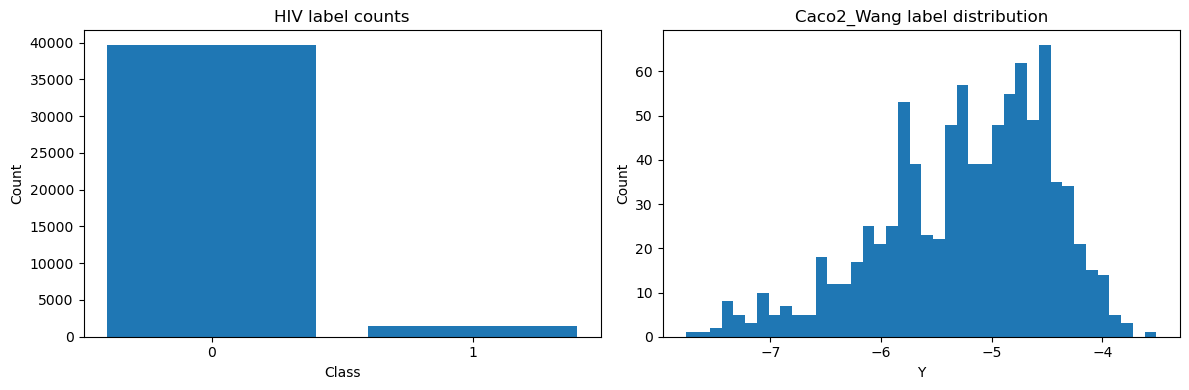

HIV class proportions:
Y
0    0.964914
1    0.035086
Name: proportion, dtype: float64

Caco2 label summary:
count    910.000000
mean      -5.239498
std        0.777236
min       -7.760000
25%       -5.777444
50%       -5.131224
75%       -4.641339
max       -3.510000
Name: Y, dtype: float64


In [6]:
# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# HIV class balance
hiv_counts = HIV_df[hiv_label_col].value_counts().sort_index()
axes[0].bar(hiv_counts.index.astype(str), hiv_counts.values)
axes[0].set_title("HIV label counts")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

# Caco2 regression distribution
axes[1].hist(caco2_df[caco2_label_col].dropna(), bins=40)
axes[1].set_title("Caco2_Wang label distribution")
axes[1].set_xlabel(caco2_label_col)
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("HIV class proportions:")
print(HIV_df[hiv_label_col].value_counts(normalize=True).sort_index())

print("\nCaco2 label summary:")
print(caco2_df[caco2_label_col].describe())

In [7]:
# Check SMILES with RDKit
def parse_smiles(smiles):
    if pd.isna(smiles):
        return None
    try:
        return Chem.MolFromSmiles(smiles)
    except Exception:
        return None

hiv_mols = HIV_df[hiv_smiles_col].apply(parse_smiles)
caco2_mols = caco2_df[caco2_smiles_col].apply(parse_smiles)

print("Valid HIV molecules:", hiv_mols.notna().sum(), "/", len(hiv_mols))
print("Valid Caco2 molecules:", caco2_mols.notna().sum(), "/", len(caco2_mols))

hiv_invalid = HIV_df.loc[hiv_mols.isna(), [hiv_smiles_col, hiv_label_col]].head()
caco2_invalid = caco2_df.loc[caco2_mols.isna(), [caco2_smiles_col, caco2_label_col]].head()

display(hiv_invalid)
display(caco2_invalid)

[10:42:13] Explicit valence for atom # 3 Al, 6, is greater than permitted
[10:42:13] Explicit valence for atom # 5 B, 5, is greater than permitted
[10:42:14] Explicit valence for atom # 16 Al, 9, is greater than permitted
[10:42:14] Explicit valence for atom # 4 Al, 9, is greater than permitted
[10:42:15] Explicit valence for atom # 12 Al, 7, is greater than permitted
[10:42:15] Explicit valence for atom # 13 Al, 7, is greater than permitted
[10:42:16] WARNING: not removing hydrogen atom without neighbors
[10:42:16] WARNING: not removing hydrogen atom without neighbors
[10:42:16] Explicit valence for atom # 8 Ge, 5, is greater than permitted


Valid HIV molecules: 41120 / 41127
Valid Caco2 molecules: 910 / 910


,Drug,Y
137,O=C1O[Al]23(OC1=O)(OC(=O)C(=O)O2)OC(=O)C(=O)O3,0
987,Cc1ccc([B-2]2(c3ccc(C)cc3)=NCCO2)cc1,0
12882,Oc1ccc(C2Oc3cc(O)cc4c3C(=[O+][AlH3-3]35([O+]=C...,0
18293,CC1=C2[OH+][AlH3-3]34([O+]=C2C=CN1C)([O+]=C1C=...,0
30784,CC(c1cccs1)=[N+]1[N-]C(N)=[S+][AlH3-]12[OH+]B(...,0


,Drug,Y


In [ ]:
#Generate fingerprints:
def morgan_fp_from_mol(mol, radius=2, n_bits=2048): # 2048 column-long fingerprint embeddings
    if mol is None:
        return None
    # https://www.rdkit.org/docs/source/rdkit.Chem.rdMolDescriptors.html#:~:text=rdkit.Chem.rdMolDescriptors.GetMorganFingerprintAsBitVect,api%3A%3Aobject%3DNone%20%5B%2Cbool%3DFalse%5D%5D%5D%5D%5D%5D%5D%5D)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    # https://www.rdkit.org/docs/cppapi/namespaceRDKit_1_1MorganFingerprints.html although MorganFingerprintAsBitVect might be deprecated
    arr = np.zeros((n_bits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr
# https://rdkit.org/docs/GettingStartedInPython.html

# extract the dataframe matrices abd get X, y, clean_df matrices for analyses
def featurize_dataframe(df, smiles_col, label_col, n_bits=2048):
    mols = df[smiles_col].apply(parse_smiles)
    fps = mols.apply(lambda m: morgan_fp_from_mol(m, n_bits=n_bits))

    mask = fps.notna() & df[label_col].notna()
    X = np.vstack(fps[mask].values)
    y = df.loc[mask, label_col].values
    clean_df = df.loc[mask].copy()

    return X, y, clean_df

X_hiv, y_hiv, hiv_clean = featurize_dataframe(HIV_df, hiv_smiles_col, hiv_label_col)
X_caco2, y_caco2, caco2_clean = featurize_dataframe(caco2_df, caco2_smiles_col, caco2_label_col)

print("HIV fingerprint matrix:", X_hiv.shape, "labels:", y_hiv.shape)
print("Caco2 fingerprint matrix:", X_caco2.shape, "labels:", y_caco2.shape)

[10:42:16] Explicit valence for atom # 3 Al, 6, is greater than permitted
[10:42:16] Explicit valence for atom # 5 B, 5, is greater than permitted
[10:42:17] Explicit valence for atom # 16 Al, 9, is greater than permitted
[10:42:17] Explicit valence for atom # 4 Al, 9, is greater than permitted
[10:42:18] Explicit valence for atom # 12 Al, 7, is greater than permitted
[10:42:18] Explicit valence for atom # 13 Al, 7, is greater than permitted
[10:42:19] WARNING: not removing hydrogen atom without neighbors
[10:42:19] WARNING: not removing hydrogen atom without neighbors
[10:42:19] Explicit valence for atom # 8 Ge, 5, is greater than permitted
[10:42:19] DEPRECATION WARNING: please use MorganGenerator
[10:42:19] DEPRECATION WARNING: please use MorganGenerator
[10:42:19] DEPRECATION WARNING: please use MorganGenerator
[10:42:19] DEPRECATION WARNING: please use MorganGenerator
[10:42:19] DEPRECATION WARNING: please use MorganGenerator
[10:42:19] DEPRECATION WARNING: please use MorganGenera

HIV fingerprint matrix: (41120, 2048) labels: (41120,)
Caco2 fingerprint matrix: (910, 2048) labels: (910,)


[10:42:22] DEPRECATION WARNING: please use MorganGenerator
[10:42:22] DEPRECATION WARNING: please use MorganGenerator
[10:42:22] DEPRECATION WARNING: please use MorganGenerator
[10:42:22] DEPRECATION WARNING: please use MorganGenerator
[10:42:22] DEPRECATION WARNING: please use MorganGenerator
[10:42:22] DEPRECATION WARNING: please use MorganGenerator
[10:42:22] DEPRECATION WARNING: please use MorganGenerator
[10:42:22] DEPRECATION WARNING: please use MorganGenerator
[10:42:22] DEPRECATION WARNING: please use MorganGenerator
[10:42:22] DEPRECATION WARNING: please use MorganGenerator
[10:42:22] DEPRECATION WARNING: please use MorganGenerator
[10:42:22] DEPRECATION WARNING: please use MorganGenerator
[10:42:22] DEPRECATION WARNING: please use MorganGenerator
[10:42:22] DEPRECATION WARNING: please use MorganGenerator
[10:42:22] DEPRECATION WARNING: please use MorganGenerator
[10:42:22] DEPRECATION WARNING: please use MorganGenerator
[10:42:22] DEPRECATION WARNING: please use MorganGenerat

In [ ]:
# How do the featres look like?
print(f"X_hiv: {X_hiv[:5, :32]}") # checking first 5 mols and 32 columns
#how many 1s per molecule:
bit_counts = X_hiv.sum(axis=1)
print(bit_counts[:10]) # if non-zero, molecules are not non-zero vectors; fingerprinting worked.

bit_frequencies = X_hiv.mean(axis=0)
print(bit_frequencies[:20])

X_hiv: [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
[17 30 35 25 10 30 18 35 24 21]
[0.00250486 0.15756323 0.03052043 0.005107   0.0234679  0.03027724
 0.00381809 0.0123784  0.01529669 0.01062743 0.00445039 0.00821984
 0.00496109 0.03382782 0.03078794 0.0042072  0.00846304 0.00308852
 0.01549125 0.00474222]


In [15]:
X_hiv_df = pd.DataFrame(X_hiv)
display(X_hiv_df.iloc[:5, :20])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


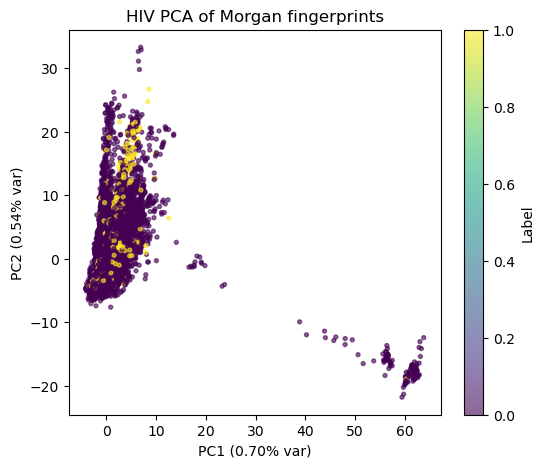

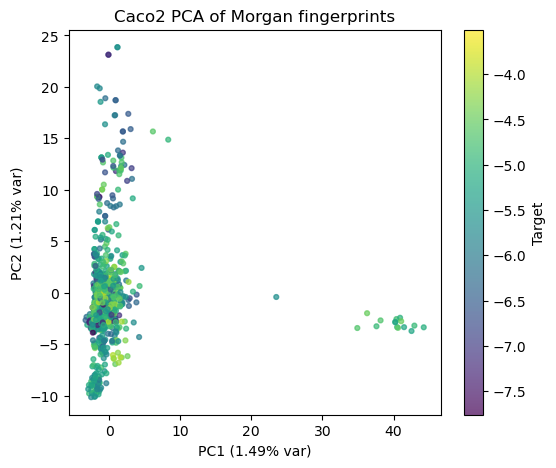

In [9]:
# PCA
def plot_pca(X, y, title, task="classification"):
    X_scaled = StandardScaler(with_mean=True, with_std=True).fit_transform(X.astype(float))
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(6,5))
    if task == "classification":
        plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=8, alpha=0.6)
        plt.colorbar(label="Label")
    else:
        sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=12, alpha=0.7)
        plt.colorbar(sc, label="Target")
    plt.title(title)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} var)")
    plt.show()

plot_pca(X_hiv, y_hiv, "HIV PCA of Morgan fingerprints", task="classification")
plot_pca(X_caco2, y_caco2, "Caco2 PCA of Morgan fingerprints", task="regression")

In [10]:
# HIV dataset: classification, perform  regression
# HIV classification baseline
clf = LogisticRegression(max_iter=2000, class_weight="balanced")

cv_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
hiv_roc = cross_val_score(clf, X_hiv, y_hiv, cv=cv_cls, scoring="roc_auc")
hiv_ap = cross_val_score(clf, X_hiv, y_hiv, cv=cv_cls, scoring="average_precision")

print(f"HIV Logistic Regression ROC-AUC: {hiv_roc.mean()} +/- {hiv_roc.std()}")
print(f"HIV Logistic Regression Avg Precision:{hiv_ap.mean()} +/- {hiv_ap.std()}")

HIV Logistic Regression ROC-AUC: 0.7988411293187054 +/- 0.021300996094478348
HIV Logistic Regression Avg Precision:0.30088239791904936 +/- 0.022099881111526873


In [11]:
# Caco2 regression baseline
reg = Ridge(alpha=1.0)

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)
caco2_mae = -cross_val_score(reg, X_caco2, y_caco2, cv=cv_reg, scoring="neg_mean_absolute_error")
caco2_r2 = cross_val_score(reg, X_caco2, y_caco2, cv=cv_reg, scoring="r2")

print("Caco2 Ridge MAE:", caco2_mae.mean(), "+/-", caco2_mae.std())
print("Caco2 Ridge R^2:", caco2_r2.mean(), "+/-", caco2_r2.std())

Caco2 Ridge MAE: 0.3711093884263573 +/- 0.014300330029358582
Caco2 Ridge R^2: 0.5961383243594737 +/- 0.04162834997648818
